In [1]:
print("Hello World")

Hello World


In [66]:
import os
import sys
import time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, date, time, timedelta
from meteostat import Point, Daily
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

#### Core Data Check / Validation

In [3]:
df  = pd.read_excel(r"C:\Users\TPWODL\New folder_Content\DeepLearning_TimeSeries_LSTM_End_To_End\data\raw\Twitter_X.xlsx")

In [4]:
df.head(5)

,SL.NO,DATE,SHIFT DUTY,QUERY/REQUEST/COMPLAINT,COMPLAINT DETAILS,COMPLAINT NUMBER,SECTION,SUB-DIVISION,DIVISION,CIRCLE,...,PSCC/FG/TO,REPEAT (Y / N),FORWARDED TO,SENTIMENTS,NATURE OF TWEET,ACTIONABLE/ NON ACTIONABLE,AGEING,SLAB,SLAB2,MINUTE
0,1,2022-06-10,NaN,NaN,Mr. Mohan Maharana complaint regarding the fun...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1243,>180,>365,0.0
1,2,2022-06-10,NaN,NaN,Mr.Bhawanispanda complaint regarding the repla...,4206102206136,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1243,>180,>365,0.0
2,3,2022-06-10,NaN,NaN,Mr. Dumb.Orator complaint regarding the unauth...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1243,>180,>365,0.0
3,4,2022-06-10,NaN,NaN,"Frequent power interuption At- Sihinapada,Masa...",NaN,NaN,NUAPADA,NUAPADA,KALAHANDI,...,NaN,NaN,NaN,NaN,NaN,NaN,1243,>180,>365,0.0
4,5,2022-06-10,NaN,NaN,Mr. akshya_patra tweeted that DTR is in unsafe...,4206102207051,SAINTALA,"SDO-2,TITLAGARH",TITLAGARH,BOLANGIR,...,NaN,NaN,NaN,NaN,NaN,NaN,1243,>180,>365,0.0


In [5]:
# Core Data Check / Validation
print("🔍 Core Data Validation")
print("Shape:", df.shape)
print("Data Types:\n", df.dtypes)

🔍 Core Data Validation
Shape: (31768, 33)
Data Types:
 SL.NO                                      int64
DATE                              datetime64[ns]
SHIFT DUTY                                object
QUERY/REQUEST/COMPLAINT                   object
COMPLAINT DETAILS                         object
COMPLAINT NUMBER                          object
SECTION                                   object
SUB-DIVISION                              object
DIVISION                                  object
CIRCLE                                    object
COMPLAINT TYPE                            object
CONSUMER NUMBER                           object
MOBILE NUMB                               object
DEPT                                      object
CLOSED/OPEN                               object
REMARKS                                   object
TWEET-LINK                                object
COMPLAINANT NAME                          object
COMPLAINT RECEIVED TIME                   object
RESPONSE TIME 

In [6]:
df.isnull().sum()

SL.NO                                 0
DATE                                  0
SHIFT DUTY                        24885
QUERY/REQUEST/COMPLAINT           29356
COMPLAINT DETAILS                     0
COMPLAINT NUMBER                  23848
SECTION                           11185
SUB-DIVISION                       7726
DIVISION                           7362
CIRCLE                             7455
COMPLAINT TYPE                        0
CONSUMER NUMBER                   21956
MOBILE NUMB                       26773
DEPT                                  0
CLOSED/OPEN                           0
REMARKS                              56
TWEET-LINK                            4
COMPLAINANT NAME                    592
COMPLAINT RECEIVED TIME             575
RESPONSE TIME                       629
SECOND RESPONSE TIME              24162
FINAL RESPONSE TIME               20861
FINAL RESPONSE DATE DD/MM/YYYY    20632
PSCC/FG/TO                        27400
REPEAT (Y / N)                    27783


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns

Index(['SL.NO', 'DATE', 'SHIFT DUTY', 'QUERY/REQUEST/COMPLAINT',
       'COMPLAINT DETAILS', 'COMPLAINT NUMBER', 'SECTION ', 'SUB-DIVISION',
       'DIVISION', 'CIRCLE', 'COMPLAINT TYPE', 'CONSUMER NUMBER',
       'MOBILE NUMB', 'DEPT', 'CLOSED/OPEN', 'REMARKS', 'TWEET-LINK',
       'COMPLAINANT NAME', 'COMPLAINT RECEIVED TIME', 'RESPONSE TIME',
       'SECOND RESPONSE TIME', 'FINAL RESPONSE TIME',
       'FINAL RESPONSE DATE DD/MM/YYYY', 'PSCC/FG/TO', 'REPEAT (Y / N)',
       'FORWARDED TO', 'SENTIMENTS', 'NATURE OF TWEET',
       'ACTIONABLE/ NON ACTIONABLE', 'AGEING', 'SLAB', 'SLAB2', 'MINUTE'],
      dtype='object')

<Axes: xlabel='DEPT'>

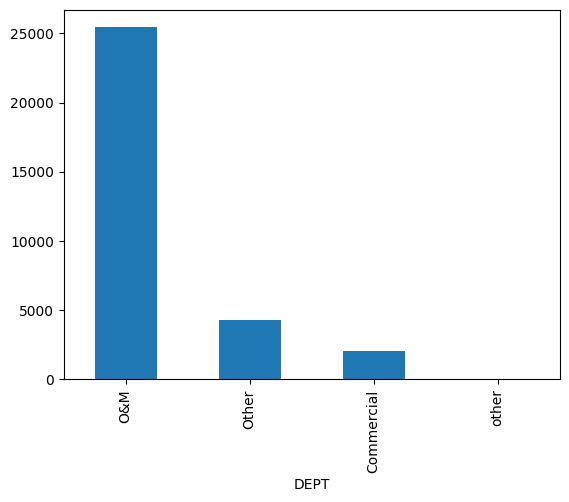

In [9]:
df['DEPT'].value_counts().plot(kind='bar')

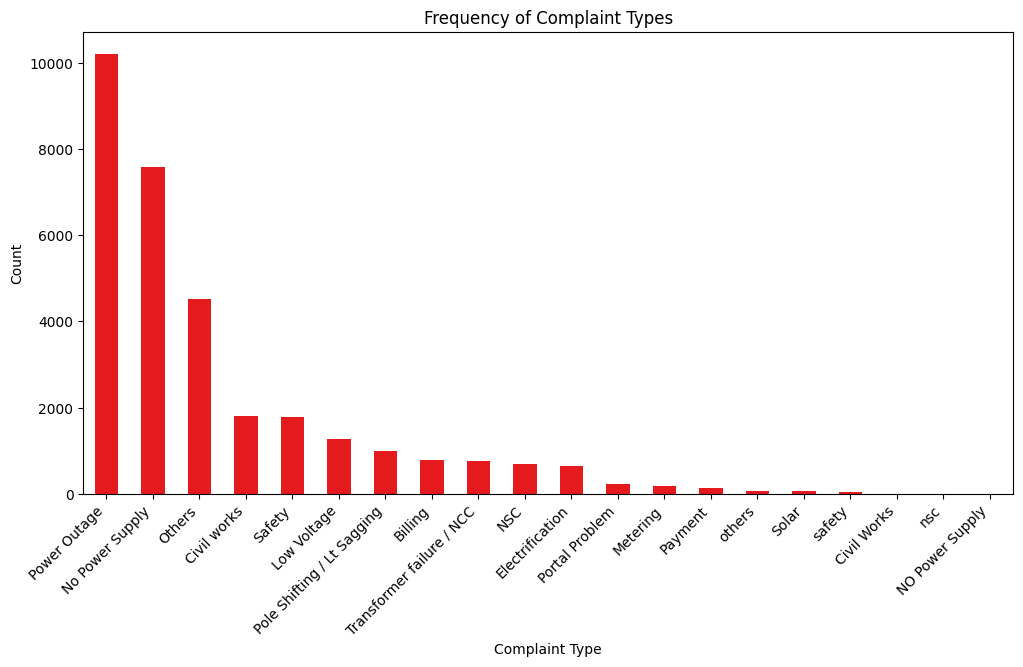

In [10]:
# Use the 'Set1' colormap, which has 9 distinct colors,
# or 'tab10' for 10 colors.
df['COMPLAINT TYPE'].value_counts().plot(
    kind='bar',
    figsize=(12, 6), # Using a good size for better viewing
    cmap='Set1'      # Applies a distinct color to each complaint type
)

# Add clear labels
plt.title('Frequency of Complaint Types')
plt.xlabel('Complaint Type')
plt.ylabel('Count')

# You may need to rotate the x-axis labels if the complaint types are long
plt.xticks(rotation=45, ha='right')

plt.show()

In [11]:
df['COMPLAINT TYPE'].value_counts()

COMPLAINT TYPE
Power Outage                  10206
No Power Supply                7579
Others                         4512
Civil works                    1797
Safety                         1784
Low Voltage                    1274
Pole Shifting / Lt Sagging      995
Billing                         776
Transformer failure / NCC       761
NSC                             700
Electrification                 653
Portal Problem                  223
Metering                        190
Payment                         131
others                           71
Solar                            69
safety                           44
Civil Works                       1
nsc                               1
NO Power Supply                   1
Name: count, dtype: int64

<Axes: xlabel='SHIFT DUTY'>

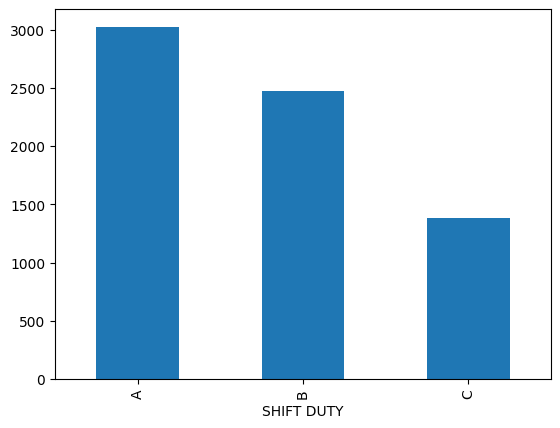

In [12]:
df['SHIFT DUTY'].value_counts().plot(kind='bar')

<Axes: xlabel='QUERY/REQUEST/COMPLAINT'>

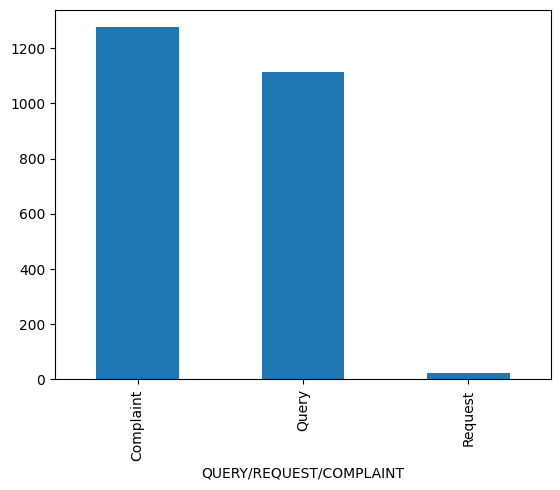

In [13]:
df['QUERY/REQUEST/COMPLAINT'].value_counts().plot(kind='bar')

<Axes: xlabel='CLOSED/OPEN'>

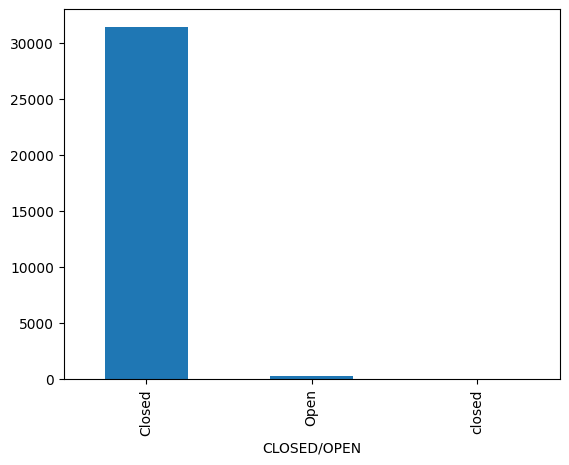

In [14]:

df['CLOSED/OPEN'].value_counts().plot(kind='bar')

<Axes: xlabel='PSCC/FG/TO'>

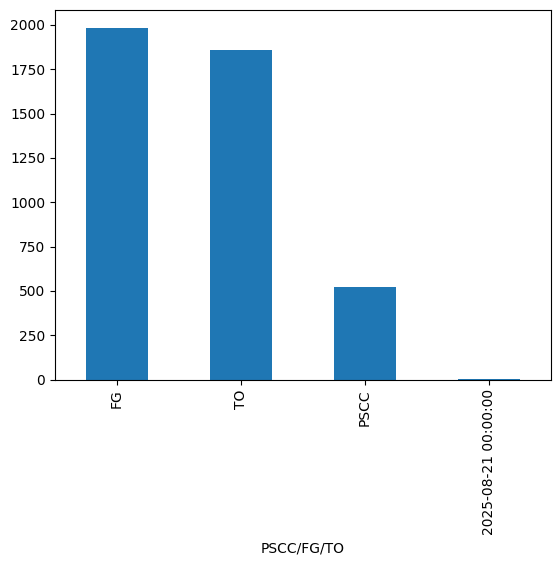

In [15]:
df['PSCC/FG/TO'].value_counts().plot(kind='bar')

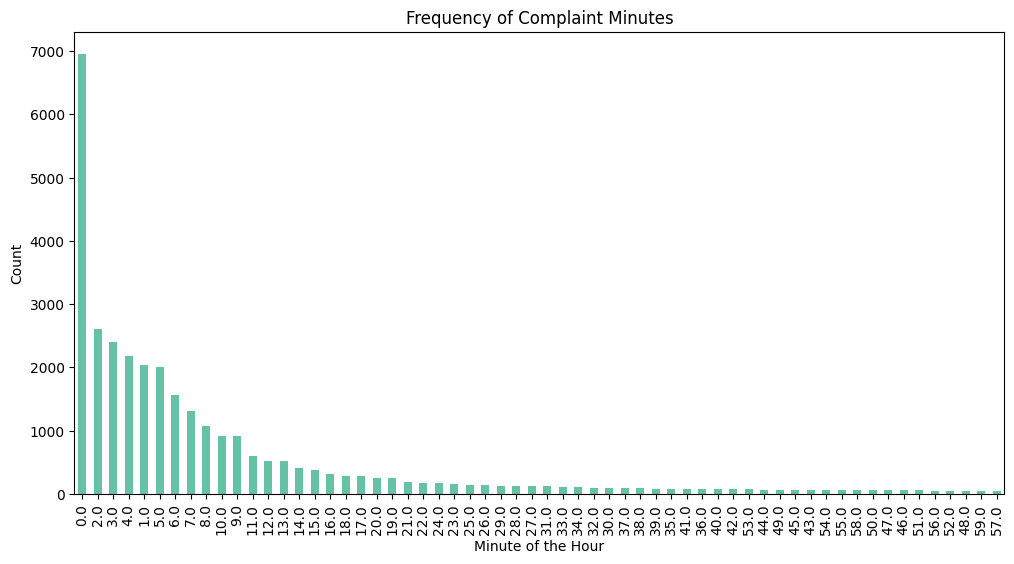

In [16]:
# The 'cmap' parameter is added to automatically apply a color map to the bars.
df['MINUTE'].value_counts().plot(
    kind='bar',
    figsize=(12, 6),
    cmap='Set2'  # Use a distinct color palette
)

plt.title('Frequency of Complaint Minutes')
plt.xlabel('Minute of the Hour')
plt.ylabel('Count')

# Display the plot
plt.show()

<Axes: xlabel='SLAB2'>

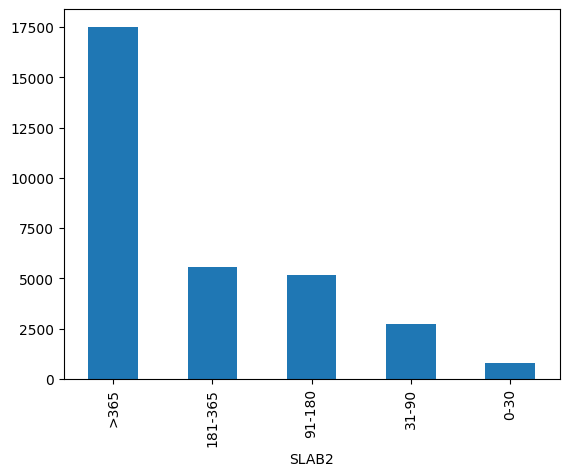

In [17]:
df['SLAB2'].value_counts().plot(kind='bar')

In [18]:
day_and_count = pd.to_datetime(df['DATE'])

In [19]:
day_and_count.info()

<class 'pandas.core.series.Series'>
RangeIndex: 31768 entries, 0 to 31767
Series name: DATE
Non-Null Count  Dtype         
--------------  -----         
31768 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 248.3 KB


In [20]:
# Group the data by date and count the occurrences
daily_counts = df.groupby('DATE').size().reset_index(name='COUNT')

In [21]:
daily_counts.head(3)

,DATE,COUNT
0,2022-06-10,10
1,2022-06-11,12
2,2022-06-12,5


In [22]:
daily_counts.tail(3)

,DATE,COUNT
1239,2025-11-01,26
1240,2025-11-02,27
1241,2025-11-03,23


In [23]:
daily_counts.shape

(1242, 2)

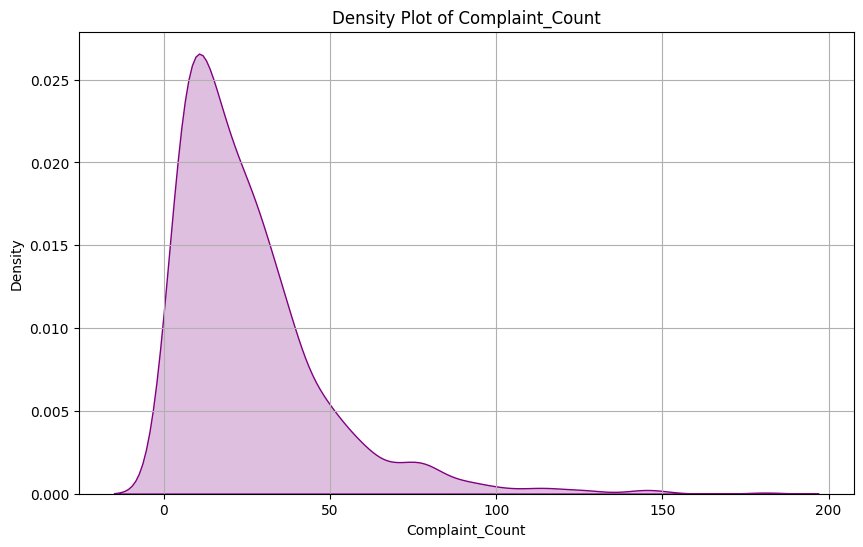

In [24]:
plt.figure(figsize=(10, 6))
sns.kdeplot(daily_counts['COUNT'], shade=True, color='purple')
plt.title('Density Plot of Complaint_Count')
plt.xlabel('Complaint_Count')
plt.ylabel('Density')
plt.grid(True)
plt.show()

In [25]:
daily_counts.shape

(1242, 2)

In [26]:
# Define the geographical coordinates and date range
latitude = 21.4669
longitude = 83.9812
start_date = datetime(2022, 6, 10)
end_date = datetime(2025, 11, 3)

# Create a Point object for the location
location = Point(latitude, longitude)

# Fetch the daily weather data
# This connects to the Meteostat API to get the data
daily_data = Daily(location, start_date, end_date)
data_frame = daily_data.fetch()

# Print the resulting DataFrame
print(data_frame)


            tavg  tmin  tmax  prcp  snow  wdir  wspd  wpgt    pres  tsun
time                                                                    
2022-06-10  35.5  30.9  41.4   0.0  <NA>  <NA>   9.2  <NA>   999.5  <NA>
2022-06-11  34.6  28.1  41.6   3.3  <NA>  <NA>  11.5  <NA>  1000.8  <NA>
2022-06-12  35.4  28.3  42.2   0.1  <NA>  <NA>   7.6  <NA>  1001.5  <NA>
2022-06-13  34.5  30.0  41.8   0.0  <NA>  <NA>   7.1  <NA>  1003.0  <NA>
2022-06-14  34.6  30.9  43.0   0.0  <NA>  <NA>   7.1  <NA>  1002.1  <NA>
...          ...   ...   ...   ...   ...   ...   ...   ...     ...   ...
2025-10-30  27.2  24.9  31.3   6.2  <NA>  <NA>  14.6  <NA>  1008.5  <NA>
2025-10-31  27.4  25.0  31.0   1.2  <NA>  <NA>  12.3  <NA>  1009.0  <NA>
2025-11-01  27.8  24.8  31.4   0.2  <NA>  <NA>   9.6  <NA>  1009.3  <NA>
2025-11-02  27.2  23.7  30.8   0.0  <NA>  <NA>   6.4  <NA>  1009.7  <NA>
2025-11-03  26.4  22.8  30.9   0.0  <NA>  <NA>   8.8  <NA>  1009.8  <NA>

[1243 rows x 10 columns]


In [27]:
data_frame

,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
time,,,,,,,,,,
2022-06-10,35.5,30.9,41.4,0.0,<NA>,<NA>,9.2,<NA>,999.5,<NA>
2022-06-11,34.6,28.1,41.6,3.3,<NA>,<NA>,11.5,<NA>,1000.8,<NA>
2022-06-12,35.4,28.3,42.2,0.1,<NA>,<NA>,7.6,<NA>,1001.5,<NA>
2022-06-13,34.5,30.0,41.8,0.0,<NA>,<NA>,7.1,<NA>,1003.0,<NA>
2022-06-14,34.6,30.9,43.0,0.0,<NA>,<NA>,7.1,<NA>,1002.1,<NA>
...,...,...,...,...,...,...,...,...,...,...
2025-10-30,27.2,24.9,31.3,6.2,<NA>,<NA>,14.6,<NA>,1008.5,<NA>
2025-10-31,27.4,25.0,31.0,1.2,<NA>,<NA>,12.3,<NA>,1009.0,<NA>
2025-11-01,27.8,24.8,31.4,0.2,<NA>,<NA>,9.6,<NA>,1009.3,<NA>


In [28]:
import requests
import pandas as pd

# ---------------------------
# Location and Date Range
# ---------------------------
latitude = 21.4669
longitude = 83.9812
start_date = "2022-06-10"
end_date   = "2025-11-03"

# ---------------------------
# Build API URL (only daily mean temperature & humidity)
# ---------------------------
url = (
    f"https://archive-api.open-meteo.com/v1/archive?"
    f"latitude={latitude}&longitude={longitude}"
    f"&start_date={start_date}&end_date={end_date}"
    f"&daily=temperature_2m_mean,relative_humidity_2m_mean"
    f"&timezone=Asia%2FKolkata"
)

print("Fetching data from:")
print(url)

# ---------------------------
# Fetch Data
# ---------------------------
response = requests.get(url)
response.raise_for_status()
data = response.json()

# ---------------------------
# Convert to DataFrame
# ---------------------------
temperature_humidity = pd.DataFrame(data["daily"])

# Convert date to datetime and set as index
temperature_humidity["time"] = pd.to_datetime(temperature_humidity["time"])

# ---------------------------
# Rename Columns for Clarity
# ---------------------------
temperature_humidity.rename(columns={
    "temperature_2m_mean": "day_temperature_C",
    "relative_humidity_2m_mean": "day_humidity_percent"
}, inplace=True)

# ---------------------------
# Display and Save
# ---------------------------
print(temperature_humidity.head())



Fetching data from:
https://archive-api.open-meteo.com/v1/archive?latitude=21.4669&longitude=83.9812&start_date=2022-06-10&end_date=2025-11-03&daily=temperature_2m_mean,relative_humidity_2m_mean&timezone=Asia%2FKolkata
        time  day_temperature_C  day_humidity_percent
0 2022-06-10               34.6                    47
1 2022-06-11               34.8                    42
2 2022-06-12               34.4                    45
3 2022-06-13               34.7                    45
4 2022-06-14               32.9                    52


In [29]:
temperature_humidity

,time,day_temperature_C,day_humidity_percent
0,2022-06-10,34.6,47
1,2022-06-11,34.8,42
2,2022-06-12,34.4,45
3,2022-06-13,34.7,45
4,2022-06-14,32.9,52
...,...,...,...
1238,2025-10-30,26.6,83
1239,2025-10-31,26.4,85
1240,2025-11-01,26.8,84
1241,2025-11-02,26.5,79


In [30]:
temperature_humidity

,time,day_temperature_C,day_humidity_percent
0,2022-06-10,34.6,47
1,2022-06-11,34.8,42
2,2022-06-12,34.4,45
3,2022-06-13,34.7,45
4,2022-06-14,32.9,52
...,...,...,...
1238,2025-10-30,26.6,83
1239,2025-10-31,26.4,85
1240,2025-11-01,26.8,84
1241,2025-11-02,26.5,79


In [31]:
# ===== CORE TIME FEATURES =====
temperature_humidity['day_of_week'] = temperature_humidity['time'].dt.dayofweek
temperature_humidity['day_of_month'] = temperature_humidity['time'].dt.day
temperature_humidity['day_of_year'] = temperature_humidity['time'].dt.dayofyear

In [32]:
temperature_humidity

,time,day_temperature_C,day_humidity_percent,day_of_week,day_of_month,day_of_year
0,2022-06-10,34.6,47,4,10,161
1,2022-06-11,34.8,42,5,11,162
2,2022-06-12,34.4,45,6,12,163
3,2022-06-13,34.7,45,0,13,164
4,2022-06-14,32.9,52,1,14,165
...,...,...,...,...,...,...
1238,2025-10-30,26.6,83,3,30,303
1239,2025-10-31,26.4,85,4,31,304
1240,2025-11-01,26.8,84,5,1,305
1241,2025-11-02,26.5,79,6,2,306


In [33]:
temperature_humidity.isnull().sum()

time                    0
day_temperature_C       0
day_humidity_percent    0
day_of_week             0
day_of_month            0
day_of_year             0
dtype: int64

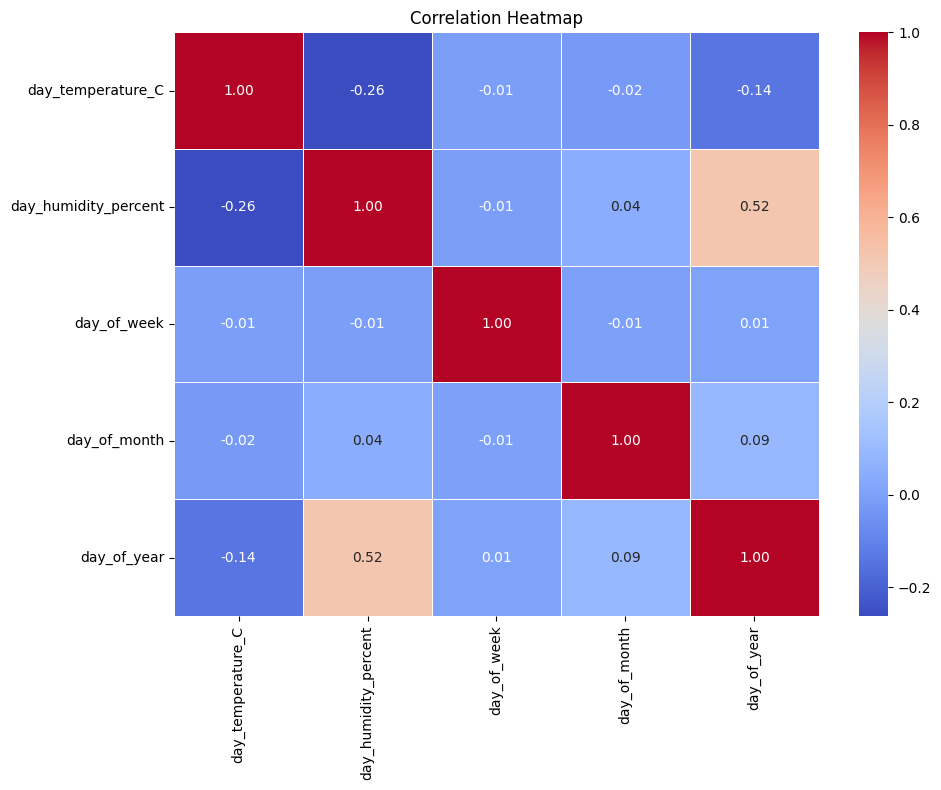

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset
# df = pd.read_csv("your_data.csv")  # Replace with your actual file

# Compute correlation matrix
corr_matrix = temperature_humidity.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


In [35]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def calculate_vif(df):
    """
    Calculate Variance Inflation Factor (VIF) for each feature in a DataFrame.
    :param df: pandas DataFrame (only numeric features)
    :return: DataFrame with VIF values
    """
    # Ensure only numeric columns
    df_numeric = df.select_dtypes(include='number').dropna()
    
    # Add a constant (intercept term)
    X = add_constant(df_numeric)
    
    # Calculate VIF for each feature
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                       for i in range(X.shape[1])]
    
    # Remove constant row for clarity
    vif_data = vif_data[vif_data["Feature"] != "const"]


    
    return vif_data.reset_index(drop=True)

In [36]:
# Assuming 'temperature_humidity' is the DataFrame
# and you want VIF for all its columns

# Try passing ONLY the DataFrame
vif_result = calculate_vif(temperature_humidity)
print(vif_result)


                Feature       VIF
0     day_temperature_C  1.074137
1  day_humidity_percent  1.439446
2           day_of_week  1.000278
3          day_of_month  1.008301
4           day_of_year  1.376902


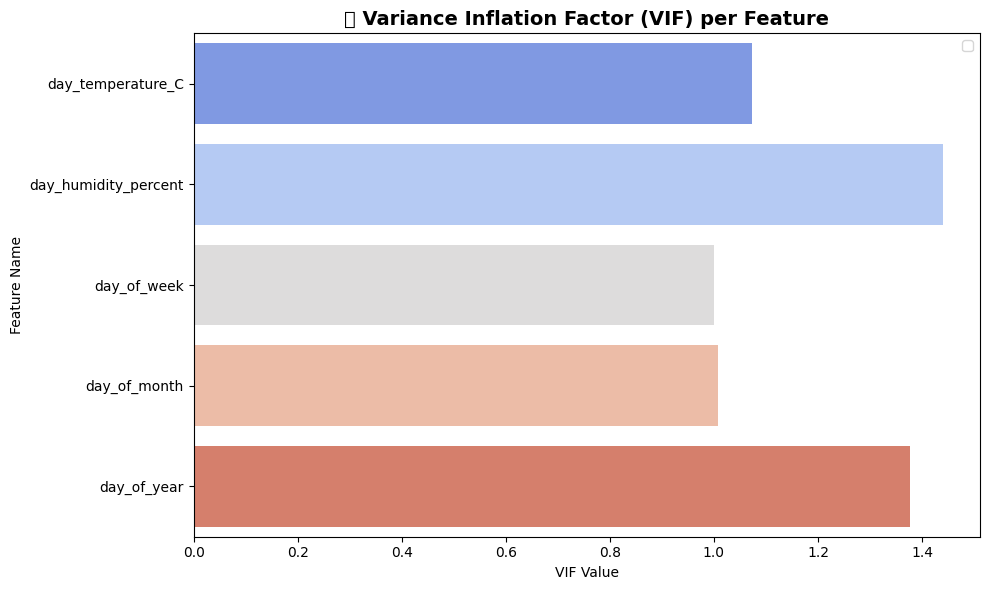

In [37]:
plt.figure(figsize=(10, 6))
sns.barplot(x="VIF", y="Feature", data=vif_result, palette="coolwarm")
plt.title("📊 Variance Inflation Factor (VIF) per Feature", fontsize=14, weight='bold')
plt.xlabel("VIF Value")
plt.ylabel("Feature Name")
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
# Ensure the input columns exist and are numeric
temperature_humidity['dayofweek_sin']  = np.sin(2 * np.pi * temperature_humidity['day_of_week'] / 7)
temperature_humidity['dayofweek_cos']  = np.cos(2 * np.pi * temperature_humidity['day_of_week'] / 7)

temperature_humidity['dayofmonth_sin'] = np.sin(2 * np.pi * temperature_humidity['day_of_month'] / 31)
temperature_humidity['dayofmonth_cos'] = np.cos(2 * np.pi * temperature_humidity['day_of_month'] / 31)

temperature_humidity['dayofyear_sin']  = np.sin(2 * np.pi * temperature_humidity['day_of_year'] / 365)
temperature_humidity['dayofyear_cos']  = np.cos(2 * np.pi * temperature_humidity['day_of_year'] / 365)

In [39]:
temperature_humidity

,time,day_temperature_C,day_humidity_percent,day_of_week,day_of_month,day_of_year,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos
0,2022-06-10,34.6,47,4,10,161,-0.433884,-0.900969,8.978045e-01,-0.440394,0.361714,-0.932289
1,2022-06-11,34.8,42,5,11,162,-0.974928,-0.222521,7.907757e-01,-0.612106,0.345612,-0.938377
2,2022-06-12,34.4,45,6,12,163,-0.781831,0.623490,6.513725e-01,-0.758758,0.329408,-0.944188
3,2022-06-13,34.7,45,0,13,164,0.000000,1.000000,4.853020e-01,-0.874347,0.313107,-0.949718
4,2022-06-14,32.9,52,1,14,165,0.781831,0.623490,2.993631e-01,-0.954139,0.296713,-0.954967
...,...,...,...,...,...,...,...,...,...,...,...,...
1238,2025-10-30,26.6,83,3,30,303,0.433884,-0.900969,-2.012985e-01,0.979530,-0.875892,0.482508
1239,2025-10-31,26.4,85,4,31,304,-0.433884,-0.900969,-2.449294e-16,1.000000,-0.867456,0.497513
1240,2025-11-01,26.8,84,5,1,305,-0.974928,-0.222521,2.012985e-01,0.979530,-0.858764,0.512371
1241,2025-11-02,26.5,79,6,2,306,-0.781831,0.623490,3.943559e-01,0.918958,-0.849817,0.527078


In [40]:
temperature_humidity.drop(columns=['day_of_week', 'day_of_month', 'day_of_year'], inplace=True)

In [41]:
temperature_humidity

,time,day_temperature_C,day_humidity_percent,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos
0,2022-06-10,34.6,47,-0.433884,-0.900969,8.978045e-01,-0.440394,0.361714,-0.932289
1,2022-06-11,34.8,42,-0.974928,-0.222521,7.907757e-01,-0.612106,0.345612,-0.938377
2,2022-06-12,34.4,45,-0.781831,0.623490,6.513725e-01,-0.758758,0.329408,-0.944188
3,2022-06-13,34.7,45,0.000000,1.000000,4.853020e-01,-0.874347,0.313107,-0.949718
4,2022-06-14,32.9,52,0.781831,0.623490,2.993631e-01,-0.954139,0.296713,-0.954967
...,...,...,...,...,...,...,...,...,...
1238,2025-10-30,26.6,83,0.433884,-0.900969,-2.012985e-01,0.979530,-0.875892,0.482508
1239,2025-10-31,26.4,85,-0.433884,-0.900969,-2.449294e-16,1.000000,-0.867456,0.497513
1240,2025-11-01,26.8,84,-0.974928,-0.222521,2.012985e-01,0.979530,-0.858764,0.512371
1241,2025-11-02,26.5,79,-0.781831,0.623490,3.943559e-01,0.918958,-0.849817,0.527078


In [42]:
temperature_humidity.isnull().sum()

time                    0
day_temperature_C       0
day_humidity_percent    0
dayofweek_sin           0
dayofweek_cos           0
dayofmonth_sin          0
dayofmonth_cos          0
dayofyear_sin           0
dayofyear_cos           0
dtype: int64

In [43]:
temperature_humidity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1243 entries, 0 to 1242
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   time                  1243 non-null   datetime64[ns]
 1   day_temperature_C     1243 non-null   float64       
 2   day_humidity_percent  1243 non-null   int64         
 3   dayofweek_sin         1243 non-null   float64       
 4   dayofweek_cos         1243 non-null   float64       
 5   dayofmonth_sin        1243 non-null   float64       
 6   dayofmonth_cos        1243 non-null   float64       
 7   dayofyear_sin         1243 non-null   float64       
 8   dayofyear_cos         1243 non-null   float64       
dtypes: datetime64[ns](1), float64(7), int64(1)
memory usage: 87.5 KB


In [44]:
temperature_humidity.columns

Index(['time', 'day_temperature_C', 'day_humidity_percent', 'dayofweek_sin',
       'dayofweek_cos', 'dayofmonth_sin', 'dayofmonth_cos', 'dayofyear_sin',
       'dayofyear_cos'],
      dtype='object')

In [45]:
daily_counts.head(2)

,DATE,COUNT
0,2022-06-10,10
1,2022-06-11,12


In [46]:
final_df = pd.concat([
    temperature_humidity[['time', 'day_temperature_C', 'day_humidity_percent',
                          'dayofweek_sin', 'dayofweek_cos',
                          'dayofmonth_sin', 'dayofmonth_cos',
                          'dayofyear_sin', 'dayofyear_cos']],
    daily_counts[['COUNT']].rename(columns={'COUNT': 'complaint_count'})
], axis=1)

In [47]:
final_df


,time,day_temperature_C,day_humidity_percent,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos,complaint_count
0,2022-06-10,34.6,47,-0.433884,-0.900969,8.978045e-01,-0.440394,0.361714,-0.932289,10.0
1,2022-06-11,34.8,42,-0.974928,-0.222521,7.907757e-01,-0.612106,0.345612,-0.938377,12.0
2,2022-06-12,34.4,45,-0.781831,0.623490,6.513725e-01,-0.758758,0.329408,-0.944188,5.0
3,2022-06-13,34.7,45,0.000000,1.000000,4.853020e-01,-0.874347,0.313107,-0.949718,15.0
4,2022-06-14,32.9,52,0.781831,0.623490,2.993631e-01,-0.954139,0.296713,-0.954967,16.0
...,...,...,...,...,...,...,...,...,...,...
1238,2025-10-30,26.6,83,0.433884,-0.900969,-2.012985e-01,0.979530,-0.875892,0.482508,23.0
1239,2025-10-31,26.4,85,-0.433884,-0.900969,-2.449294e-16,1.000000,-0.867456,0.497513,26.0
1240,2025-11-01,26.8,84,-0.974928,-0.222521,2.012985e-01,0.979530,-0.858764,0.512371,27.0
1241,2025-11-02,26.5,79,-0.781831,0.623490,3.943559e-01,0.918958,-0.849817,0.527078,23.0


In [48]:
final_df.isnull().sum()

time                    0
day_temperature_C       0
day_humidity_percent    0
dayofweek_sin           0
dayofweek_cos           0
dayofmonth_sin          0
dayofmonth_cos          0
dayofyear_sin           0
dayofyear_cos           0
complaint_count         1
dtype: int64

In [49]:
final_df.dropna(inplace=True)

In [50]:
final_df

,time,day_temperature_C,day_humidity_percent,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos,complaint_count
0,2022-06-10,34.6,47,-0.433884,-0.900969,8.978045e-01,-0.440394,0.361714,-0.932289,10.0
1,2022-06-11,34.8,42,-0.974928,-0.222521,7.907757e-01,-0.612106,0.345612,-0.938377,12.0
2,2022-06-12,34.4,45,-0.781831,0.623490,6.513725e-01,-0.758758,0.329408,-0.944188,5.0
3,2022-06-13,34.7,45,0.000000,1.000000,4.853020e-01,-0.874347,0.313107,-0.949718,15.0
4,2022-06-14,32.9,52,0.781831,0.623490,2.993631e-01,-0.954139,0.296713,-0.954967,16.0
...,...,...,...,...,...,...,...,...,...,...
1237,2025-10-29,26.2,86,0.974928,-0.222521,-3.943559e-01,0.918958,-0.884068,0.467359,43.0
1238,2025-10-30,26.6,83,0.433884,-0.900969,-2.012985e-01,0.979530,-0.875892,0.482508,23.0
1239,2025-10-31,26.4,85,-0.433884,-0.900969,-2.449294e-16,1.000000,-0.867456,0.497513,26.0
1240,2025-11-01,26.8,84,-0.974928,-0.222521,2.012985e-01,0.979530,-0.858764,0.512371,27.0


In [51]:
final_df.isnull().sum()

time                    0
day_temperature_C       0
day_humidity_percent    0
dayofweek_sin           0
dayofweek_cos           0
dayofmonth_sin          0
dayofmonth_cos          0
dayofyear_sin           0
dayofyear_cos           0
complaint_count         0
dtype: int64

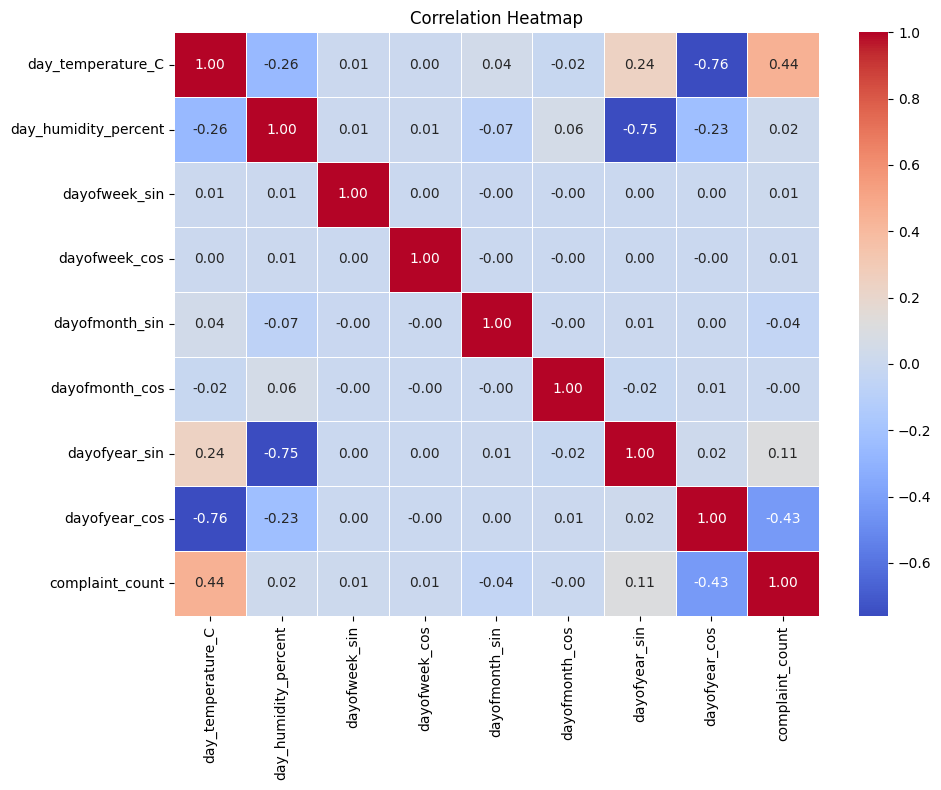

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset
# df = pd.read_csv("your_data.csv")  # Replace with your actual file

# Compute correlation matrix
corrmatrix = final_df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corrmatrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


In [53]:
final_df.head(2)

,time,day_temperature_C,day_humidity_percent,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos,complaint_count
0,2022-06-10,34.6,47,-0.433884,-0.900969,0.897805,-0.440394,0.361714,-0.932289,10.0
1,2022-06-11,34.8,42,-0.974928,-0.222521,0.790776,-0.612106,0.345612,-0.938377,12.0


In [54]:
final_df.shape

(1242, 10)

In [89]:
final_df.head(2)


,time,day_temperature_C,day_humidity_percent,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos,complaint_count
0,2022-06-10,34.6,47,-0.433884,-0.900969,0.897805,-0.440394,0.361714,-0.932289,10.0
1,2022-06-11,34.8,42,-0.974928,-0.222521,0.790776,-0.612106,0.345612,-0.938377,12.0


In [ ]:
# final_df.to_csv("twitter_complaint_data.csv", index=False)

Manual Outlier Cutoffs → Lower: 0, Upper: 90
Original Shape: (1242, 10)
Filtered Shape: (1219, 10)


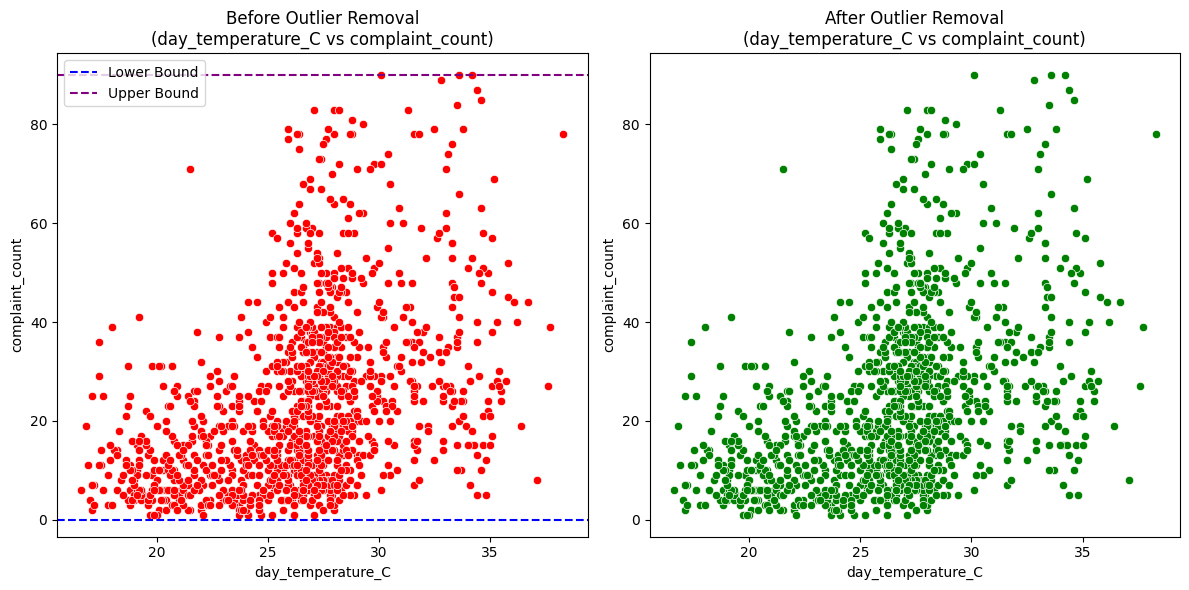

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Define your columns ---
target_col = 'complaint_count'        # 🔁 your target column
X_feature = 'day_temperature_C'    # 🔁 your x-axis feature (e.g., 'humidity', 'day', etc.)

# --- Step 2: Define manual cutoff values ---
lowerbound = 0     # 👈 set your lower limit
upperbound = 90    # 👈 set your upper limit

# --- Step 3: Apply filtering based on manual cutoffs ---
df = final_df[(final_df[target_col] >= lowerbound) & (final_df[target_col] <= upperbound)]

print(f"Manual Outlier Cutoffs → Lower: {lowerbound}, Upper: {upperbound}")
print("Original Shape:", final_df.shape)
print("Filtered Shape:", df.shape)

# --- Step 4: Scatter Plot Visualization ---
plt.figure(figsize=(12, 6))

# Before outlier removal
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x=X_feature, y=target_col, color='red', alpha=1)
plt.axhline(lowerbound, color='blue', linestyle='--', label='Lower Bound')
plt.axhline(upperbound, color='purple', linestyle='--', label='Upper Bound')
plt.legend()
plt.title(f"Before Outlier Removal\n({X_feature} vs {target_col})")

# After outlier removal
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x=X_feature, y=target_col, color='green', alpha=1)
plt.title(f"After Outlier Removal\n({X_feature} vs {target_col})")

plt.tight_layout()
plt.show()


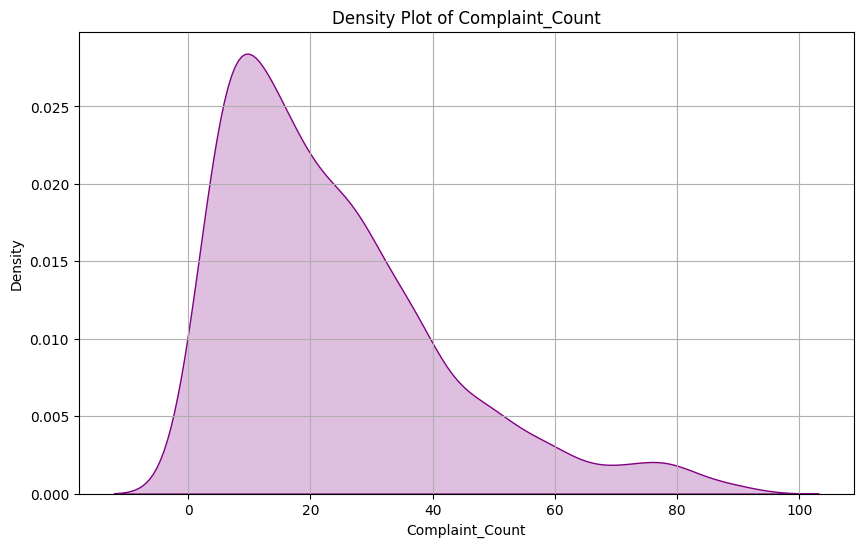

In [56]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df['complaint_count'], shade=True, color='purple')
plt.title('Density Plot of Complaint_Count')
plt.xlabel('Complaint_Count')
plt.ylabel('Density')
plt.grid(True)
plt.show()

In [57]:
df.shape

(1219, 10)

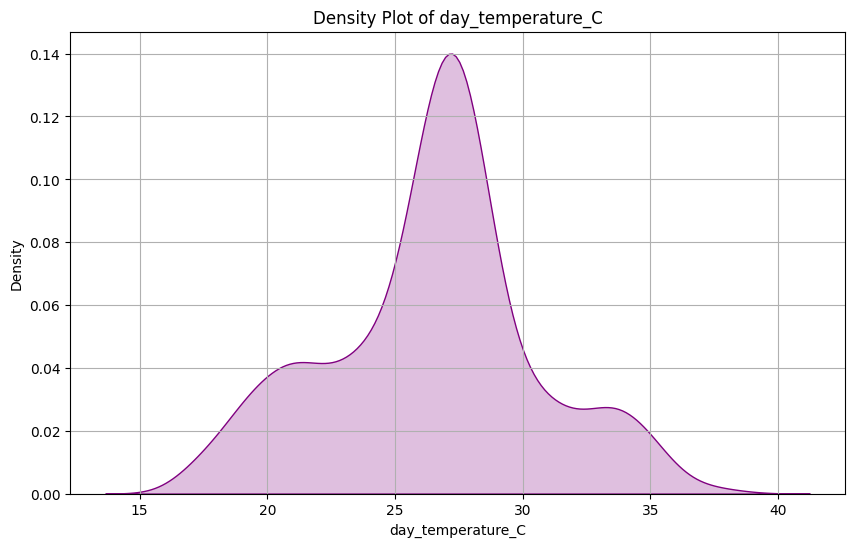

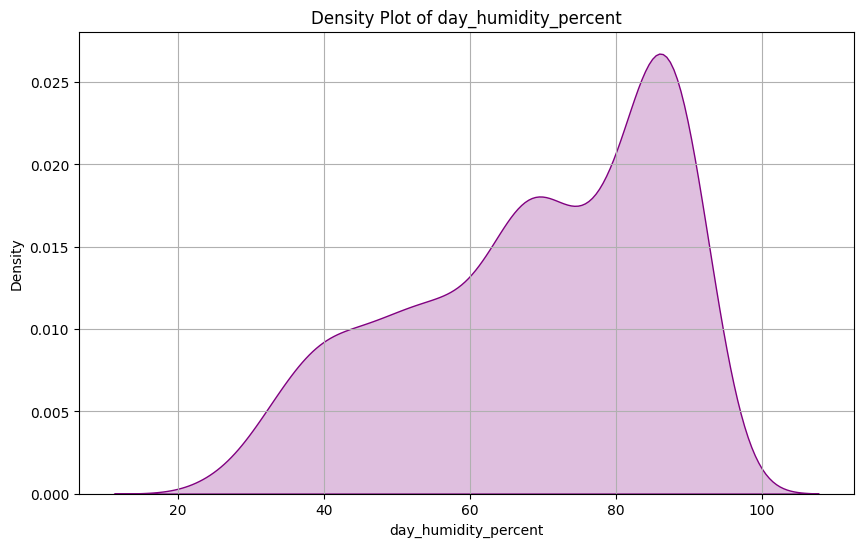

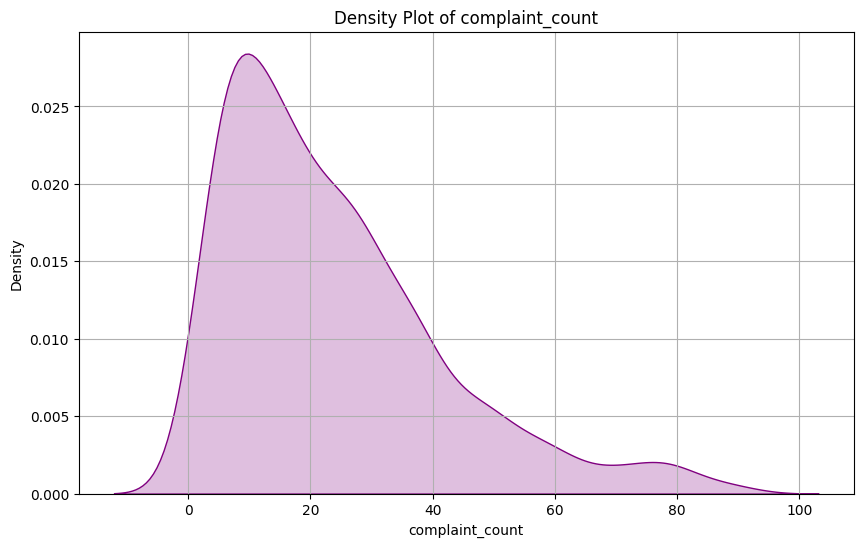

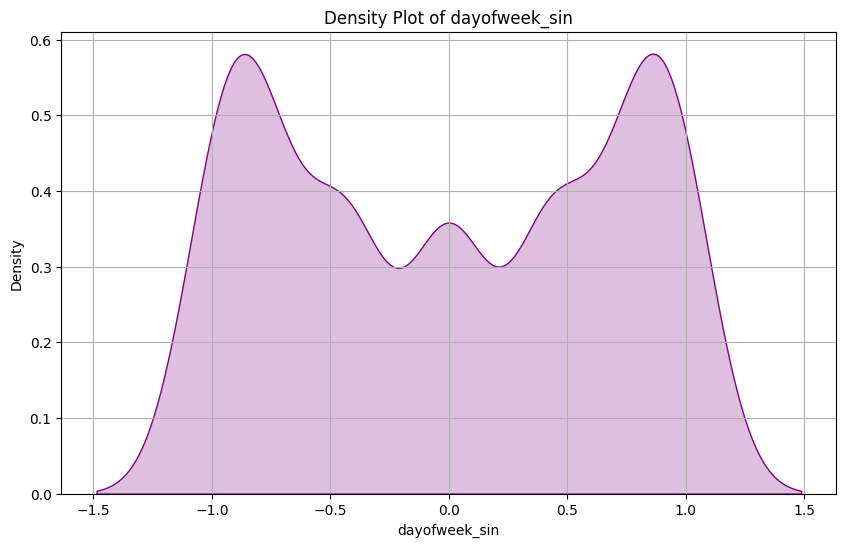

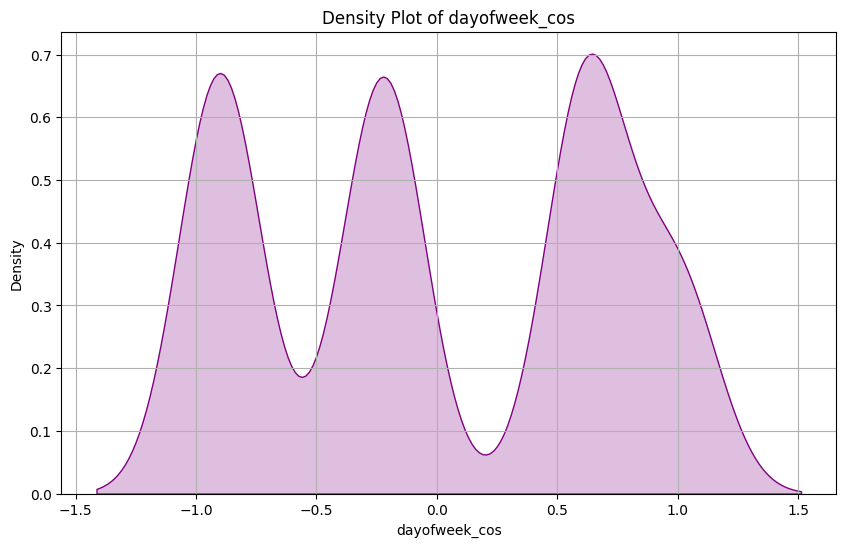

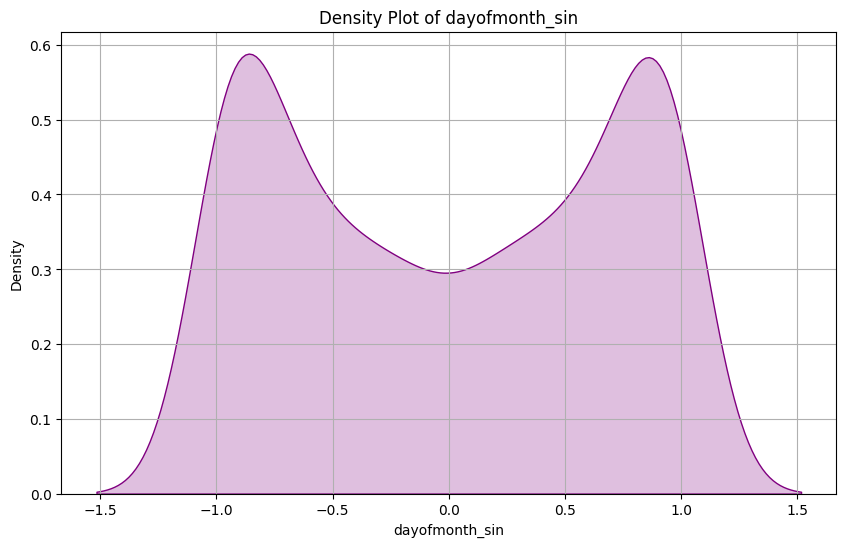

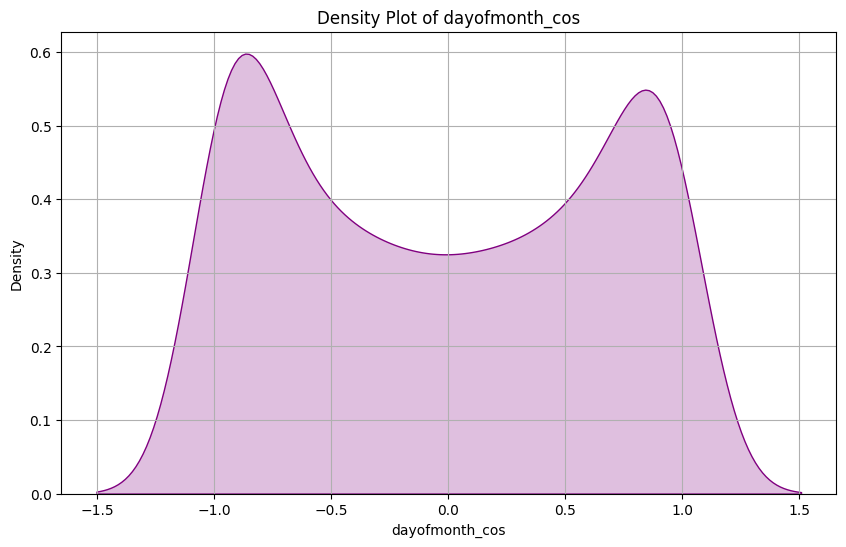

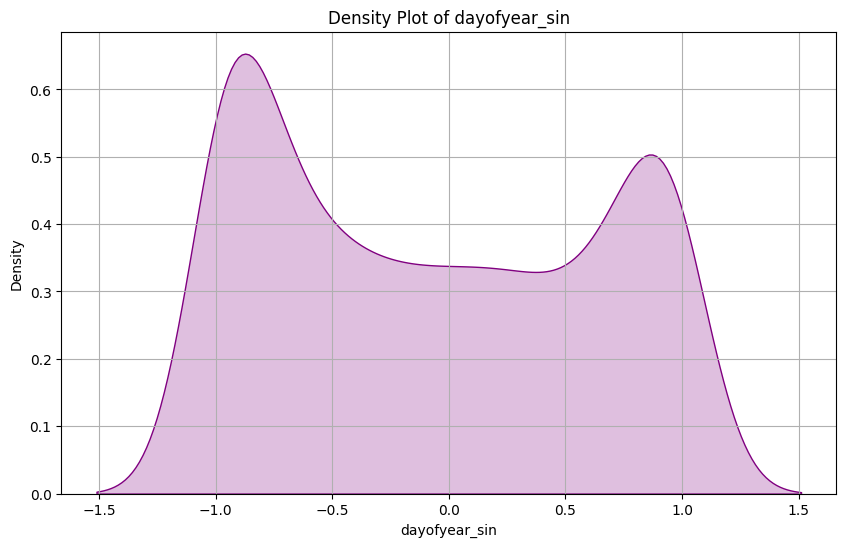

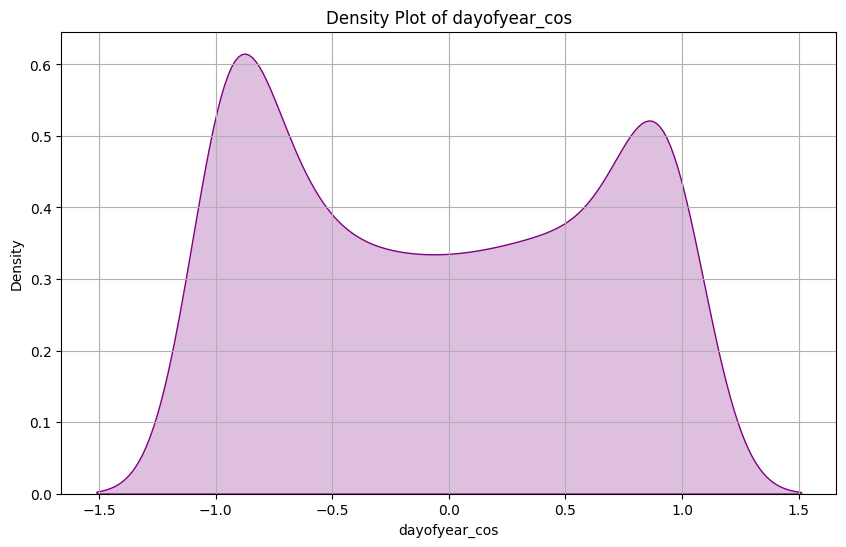

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of columns to plot
columns_to_plot = [
    'day_temperature_C', 'day_humidity_percent', 'complaint_count',
    'dayofweek_sin', 'dayofweek_cos',
    'dayofmonth_sin', 'dayofmonth_cos',
    'dayofyear_sin', 'dayofyear_cos'
]

# Loop through each column and plot KDE
for col in columns_to_plot:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(df[col], shade=True, color='purple')
    plt.title(f'Density Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.grid(True)
    plt.show()

In [58]:
df

,time,day_temperature_C,day_humidity_percent,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos,complaint_count
0,2022-06-10,34.6,47,-0.433884,-0.900969,8.978045e-01,-0.440394,0.361714,-0.932289,10.0
1,2022-06-11,34.8,42,-0.974928,-0.222521,7.907757e-01,-0.612106,0.345612,-0.938377,12.0
2,2022-06-12,34.4,45,-0.781831,0.623490,6.513725e-01,-0.758758,0.329408,-0.944188,5.0
3,2022-06-13,34.7,45,0.000000,1.000000,4.853020e-01,-0.874347,0.313107,-0.949718,15.0
4,2022-06-14,32.9,52,0.781831,0.623490,2.993631e-01,-0.954139,0.296713,-0.954967,16.0
...,...,...,...,...,...,...,...,...,...,...
1237,2025-10-29,26.2,86,0.974928,-0.222521,-3.943559e-01,0.918958,-0.884068,0.467359,43.0
1238,2025-10-30,26.6,83,0.433884,-0.900969,-2.012985e-01,0.979530,-0.875892,0.482508,23.0
1239,2025-10-31,26.4,85,-0.433884,-0.900969,-2.449294e-16,1.000000,-0.867456,0.497513,26.0
1240,2025-11-01,26.8,84,-0.974928,-0.222521,2.012985e-01,0.979530,-0.858764,0.512371,27.0


In [61]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Columns to scale
scale_cols = ['day_temperature_C', 'day_humidity_percent', 'complaint_count']

# Initialize scaler
scaler = MinMaxScaler()

# Fit on selected columns and transform
df[scale_cols] = scaler.fit_transform(df[scale_cols])

# View scaled DataFrame
# print(df)


In [62]:
df

,time,day_temperature_C,day_humidity_percent,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos,complaint_count
0,2022-06-10,0.829493,0.323944,-0.433884,-0.900969,8.978045e-01,-0.440394,0.361714,-0.932289,0.101124
1,2022-06-11,0.838710,0.253521,-0.974928,-0.222521,7.907757e-01,-0.612106,0.345612,-0.938377,0.123596
2,2022-06-12,0.820276,0.295775,-0.781831,0.623490,6.513725e-01,-0.758758,0.329408,-0.944188,0.044944
3,2022-06-13,0.834101,0.295775,0.000000,1.000000,4.853020e-01,-0.874347,0.313107,-0.949718,0.157303
4,2022-06-14,0.751152,0.394366,0.781831,0.623490,2.993631e-01,-0.954139,0.296713,-0.954967,0.168539
...,...,...,...,...,...,...,...,...,...,...
1237,2025-10-29,0.442396,0.873239,0.974928,-0.222521,-3.943559e-01,0.918958,-0.884068,0.467359,0.471910
1238,2025-10-30,0.460829,0.830986,0.433884,-0.900969,-2.012985e-01,0.979530,-0.875892,0.482508,0.247191
1239,2025-10-31,0.451613,0.859155,-0.433884,-0.900969,-2.449294e-16,1.000000,-0.867456,0.497513,0.280899
1240,2025-11-01,0.470046,0.845070,-0.974928,-0.222521,2.012985e-01,0.979530,-0.858764,0.512371,0.292135


In [63]:
df.set_index('time', inplace=True)

In [64]:
df

,day_temperature_C,day_humidity_percent,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos,complaint_count
time,,,,,,,,,
2022-06-10,0.829493,0.323944,-0.433884,-0.900969,8.978045e-01,-0.440394,0.361714,-0.932289,0.101124
2022-06-11,0.838710,0.253521,-0.974928,-0.222521,7.907757e-01,-0.612106,0.345612,-0.938377,0.123596
2022-06-12,0.820276,0.295775,-0.781831,0.623490,6.513725e-01,-0.758758,0.329408,-0.944188,0.044944
2022-06-13,0.834101,0.295775,0.000000,1.000000,4.853020e-01,-0.874347,0.313107,-0.949718,0.157303
2022-06-14,0.751152,0.394366,0.781831,0.623490,2.993631e-01,-0.954139,0.296713,-0.954967,0.168539
...,...,...,...,...,...,...,...,...,...
2025-10-29,0.442396,0.873239,0.974928,-0.222521,-3.943559e-01,0.918958,-0.884068,0.467359,0.471910
2025-10-30,0.460829,0.830986,0.433884,-0.900969,-2.012985e-01,0.979530,-0.875892,0.482508,0.247191
2025-10-31,0.451613,0.859155,-0.433884,-0.900969,-2.449294e-16,1.000000,-0.867456,0.497513,0.280899


In [ ]:
# Separate features (X) and target (y)
X = df.drop(columns=['complaint_count'])
y = df['complaint_count']
# Split data into train and test sets (80-20 split)
train_size = int(len(df) * 0.8)
y_train, y_test = y[:train_size], y[train_size:]
X_train, X_test = X[:train_size], X[train_size:]
# Print shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print(f"Training set size: {len(y_train)}")
print(f"Test set size: {len(y_test)}")
print(f"Date range - Train: {df.index[0]} to {df.index[train_size-1]}")
print(f"Date range - Test: {df.index[train_size]} to {df.index[-1]}")

X_train shape: (975, 8)
X_test shape: (244, 8)
y_train shape: (975,)
y_test shape: (244,)
Training set size: 975
Test set size: 244
Date range - Train: 2022-06-10 00:00:00 to 2025-02-17 00:00:00
Date range - Test: 2025-02-18 00:00:00 to 2025-11-02 00:00:00


In [67]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [72]:
# X_train
# y_train

# X_test
# y_test

In [75]:
# CREATE SEQUENCES FOR LSTM
def create_sequences(X, y, lookback=7):
    """Create sequences for LSTM model"""
    X_seq, y_seq = [], []
    for i in range(len(X) - lookback):
        X_seq.append(X[i:i+lookback])
        y_seq.append(y[i+lookback])
    return np.array(X_seq), np.array(y_seq)
lookback = 7  # Use previous 5 days to predict next day
X_train_seq, y_train_seq = create_sequences(X_train, y_train, lookback)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, lookback)

print(f"Training sequence shape: {X_train_seq.shape}")
print(f"Test sequence shape: {X_test_seq.shape}")

Training sequence shape: (968, 7, 8)
Test sequence shape: (237, 7, 8)


In [76]:
X_train_seq

array([[[ 0.82949309,  0.32394366, -0.43388374, ..., -0.44039415,
          0.36171373, -0.93228921],
        [ 0.83870968,  0.25352113, -0.97492791, ..., -0.61210598,
          0.34561231, -0.93837739],
        [ 0.8202765 ,  0.29577465, -0.78183148, ..., -0.75875812,
          0.32940848, -0.94418751],
        ...,
        [ 0.75115207,  0.3943662 ,  0.78183148, ..., -0.95413926,
          0.29671282, -0.95496675],
        [ 0.64976959,  0.5915493 ,  0.97492791, ..., -0.99486932,
          0.28023068, -0.95993269],
        [ 0.6359447 ,  0.61971831,  0.43388374, ..., -0.99486932,
          0.26366549, -0.96461418]],

       [[ 0.83870968,  0.25352113, -0.97492791, ..., -0.61210598,
          0.34561231, -0.93837739],
        [ 0.8202765 ,  0.29577465, -0.78183148, ..., -0.75875812,
          0.32940848, -0.94418751],
        [ 0.83410138,  0.29577465,  0.        , ..., -0.87434662,
          0.31310704, -0.94971784],
        ...,
        [ 0.64976959,  0.5915493 ,  0.97492791, ..., -

In [78]:

model = Sequential([
    LSTM(units=64, return_sequences=True, input_shape=(lookback, X_train_seq.shape[2])),
    Dropout(0.2),
    
    LSTM(units=32, return_sequences=True),
    Dropout(0.2),
    
    LSTM(units=16, return_sequences=False),
    Dropout(0.2),
    
    Dense(units=8, activation='relu'),
    Dense(units=1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
print(model.summary())


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 7, 64)          │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 7, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,385 (134.32 KB)

 Trainable params: 34,385 (134.32 KB)

 Non-trainable params: 0 (0.00 B)

None


In [79]:
# 5. CALLBACKS FOR BETTER TRAINING

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    

In [80]:
# 6. TRAIN THE MODEL

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=early_stop,
    verbose=1
)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1233 - mae: 0.3266 - val_loss: 0.0712 - val_mae: 0.2434
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1169 - mae: 0.3176 - val_loss: 0.0685 - val_mae: 0.2380
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1132 - mae: 0.3122 - val_loss: 0.0659 - val_mae: 0.2327
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1097 - mae: 0.3068 - val_loss: 0.0634 - val_mae: 0.2276
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1062 - mae: 0.3016 - val_loss: 0.0610 - val_mae: 0.2225
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1029 - mae: 0.2964 - val_loss: 0.0587 - val_mae: 0.2175
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0996 - mae: 0.2913 - val_loss: 0.0565 - val_mae: 0.2127
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0965 - mae: 0.2863 - val_loss: 0.0544 - val_mae: 0.2079
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.09

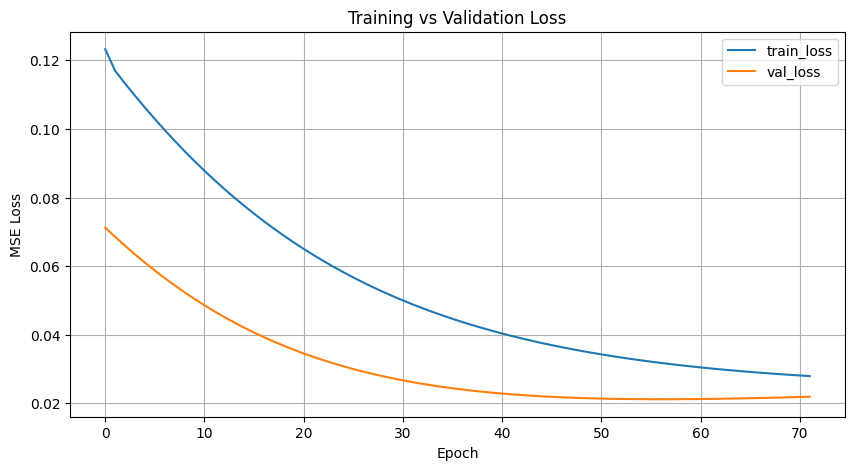

In [82]:
# 7) Plot training vs validation loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()